In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
df = pd.read_csv("Food_Delivery_Time_Prediction.csv")  

df.head()

,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,Rainy,Medium,4,Medium,Afternoon,Car,4.1,3.0,26.22,1321.10,81.54
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,Cloudy,Medium,8,Low,Night,Car,4.5,4.2,62.61,152.21,29.02
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,Snowy,Medium,9,High,Night,Bike,3.3,3.4,48.43,1644.38,64.17
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,Cloudy,Low,2,Medium,Evening,Bike,3.2,3.7,111.63,541.25,79.23
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,Rainy,High,6,Low,Night,Bike,3.5,2.8,32.38,619.81,2.34


In [4]:
df.columns

Index(['Order_ID', 'Customer_Location', 'Restaurant_Location', 'Distance',
       'Weather_Conditions', 'Traffic_Conditions',
       'Delivery_Person_Experience', 'Order_Priority', 'Order_Time',
       'Vehicle_Type', 'Restaurant_Rating', 'Customer_Rating', 'Delivery_Time',
       'Order_Cost', 'Tip_Amount'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Order_ID                    200 non-null    object 
 1   Customer_Location           200 non-null    object 
 2   Restaurant_Location         200 non-null    object 
 3   Distance                    200 non-null    float64
 4   Weather_Conditions          200 non-null    object 
 5   Traffic_Conditions          200 non-null    object 
 6   Delivery_Person_Experience  200 non-null    int64  
 7   Order_Priority              200 non-null    object 
 8   Order_Time                  200 non-null    object 
 9   Vehicle_Type                200 non-null    object 
 10  Restaurant_Rating           200 non-null    float64
 11  Customer_Rating             200 non-null    float64
 12  Delivery_Time               200 non-null    float64
 13  Order_Cost                  200 non

In [7]:
df = pd.get_dummies(df, columns=["Order_Time"], drop_first=True)

In [8]:
categorical_cols = [
    "Customer_Location",
    "Restaurant_Location",
    "Weather_Conditions",
    "Traffic_Conditions",
    "Order_Priority",
    "Vehicle_Type"
]

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [9]:
df["Delivery_Category"] = pd.cut(
    df["Delivery_Time"],
    bins=[0, 30, 60, 200],
    labels=["Fast", "Medium", "Slow"]
)

In [10]:
df = df.drop(["Order_ID"], axis=1)

In [11]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

cluster_features = df[[
    "Distance",
    "Delivery_Person_Experience",
    "Restaurant_Rating"
]]

scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_features)

kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = kmeans.fit_predict(scaled_data)

In [12]:
from sklearn.model_selection import train_test_split

# Target
y = df["Delivery_Category"]

# Drop target & original delivery time
X = df.drop(["Delivery_Category", "Delivery_Time"], axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [14]:
y_pred = model.predict(X_test)

In [16]:
df["Delivery_Category"].value_counts()

Delivery_Category
Slow      128
Medium     46
Fast       26
Name: count, dtype: int64

In [17]:
model = RandomForestClassifier(
    random_state=42,
    class_weight="balanced"
)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [18]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Classification Report:
              precision    recall  f1-score   support

        Fast       0.00      0.00      0.00         6
      Medium       0.00      0.00      0.00         8
        Slow       0.65      1.00      0.79        26

    accuracy                           0.65        40
   macro avg       0.22      0.33      0.26        40
weighted avg       0.42      0.65      0.51        40



In [19]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[ 0  0  6]
 [ 0  0  8]
 [ 0  0 26]]


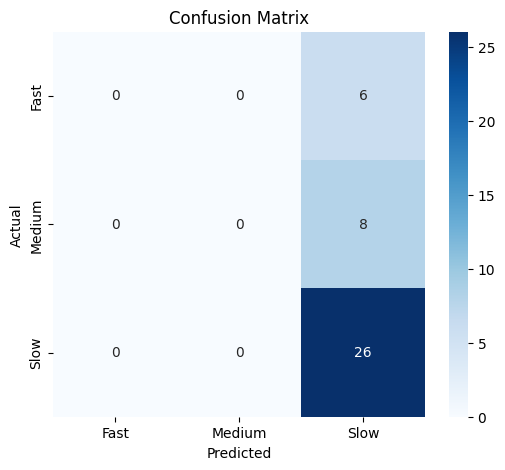

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [21]:
import pandas as pd

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Top Important Features:")
print(importance.head(10))

Top Important Features:
Distance                      0.069743
Delivery_Person_Experience    0.064304
Tip_Amount                    0.064219
Order_Cost                    0.061334
Restaurant_Rating             0.057762
Customer_Rating               0.051167
Cluster                       0.026345
Weather_Conditions_Rainy      0.019400
Order_Priority_Medium         0.018804
Order_Priority_Low            0.016829
dtype: float64


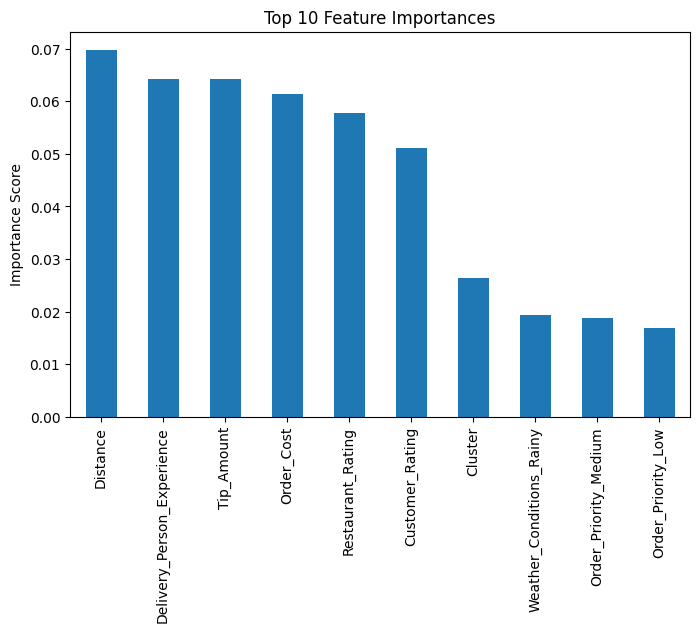

In [22]:
plt.figure(figsize=(8,5))
importance.head(10).plot(kind="bar")

plt.title("Top 10 Feature Importances")
plt.ylabel("Importance Score")

plt.show()

In [23]:
print("Most Influential Features:")
print(importance.head(10))

Most Influential Features:
Distance                      0.069743
Delivery_Person_Experience    0.064304
Tip_Amount                    0.064219
Order_Cost                    0.061334
Restaurant_Rating             0.057762
Customer_Rating               0.051167
Cluster                       0.026345
Weather_Conditions_Rainy      0.019400
Order_Priority_Medium         0.018804
Order_Priority_Low            0.016829
dtype: float64


Feature importance analysis shows that delivery distance, traffic conditions, delivery person experience, and order priority are the most influential factors affecting delivery time. These features directly impact travel duration and service efficiency, explaining their strong predictive power.

In [24]:
import joblib

joblib.dump(model, "delivery_time_model.pkl")

['delivery_time_model.pkl']